In [1]:
import pandas as pd
file_path = '../data/raw/MachineLearningRating_v3.txt' 
#|  pipe character
df= pd.read_csv(file_path , sep='|')

C:\Users\KIDIST\AppData\Local\Temp\ipykernel_14976\306786724.py:4: DtypeWarning: Columns (32,37) have mixed types. Specify dtype option on import or set low_memory=False.
  df= pd.read_csv(file_path , sep='|')


In [3]:
print(df.head())
print(df.shape)
print(df.columns)
print(df.info())

   UnderwrittenCoverID  PolicyID     TransactionMonth  IsVATRegistered  \
0               145249     12827  2015-03-01 00:00:00             True   
1               145249     12827  2015-05-01 00:00:00             True   
2               145249     12827  2015-07-01 00:00:00             True   
3               145255     12827  2015-05-01 00:00:00             True   
4               145255     12827  2015-07-01 00:00:00             True   

  Citizenship          LegalType Title Language                 Bank  \
0              Close Corporation    Mr  English  First National Bank   
1              Close Corporation    Mr  English  First National Bank   
2              Close Corporation    Mr  English  First National Bank   
3              Close Corporation    Mr  English  First National Bank   
4              Close Corporation    Mr  English  First National Bank   

       AccountType  ...                    ExcessSelected CoverCategory  \
0  Current account  ...             Mobility - 

In [2]:
df[ df.columns[32] ] = pd.to_numeric(df[ df.columns[32] ], errors='coerce')
df[ df.columns[37] ] = pd.to_numeric(df[ df.columns[37] ], errors='coerce')
df= pd.read_csv(file_path , sep='|', low_memory=False)

In [10]:
# Convert date columns
df['TransactionMonth'] = pd.to_datetime(df['TransactionMonth'], errors='coerce')

# Clean column names (optional, for easier use)
df.columns = df.columns.str.strip().str.replace(" ", "_")


In [11]:
print(df.head())

   UnderwrittenCoverID  PolicyID TransactionMonth  IsVATRegistered  \
0               145249     12827       2015-03-01             True   
1               145249     12827       2015-05-01             True   
2               145249     12827       2015-07-01             True   
3               145255     12827       2015-05-01             True   
4               145255     12827       2015-07-01             True   

  Citizenship          LegalType Title Language                 Bank  \
0              Close Corporation    Mr  English  First National Bank   
1              Close Corporation    Mr  English  First National Bank   
2              Close Corporation    Mr  English  First National Bank   
3              Close Corporation    Mr  English  First National Bank   
4              Close Corporation    Mr  English  First National Bank   

       AccountType  ...                    ExcessSelected CoverCategory  \
0  Current account  ...             Mobility - Windscreen    Windscreen

In [12]:
# Descriptive statistics for numeric variables
print(df.describe())

# Number of missing values
print(df.isnull().sum())

# Unique values for object (categorical) columns
print(df.select_dtypes(include='object').nunique())


       UnderwrittenCoverID      PolicyID               TransactionMonth  \
count         1.000098e+06  1.000098e+06                        1000098   
mean          1.048175e+05  7.956682e+03  2015-02-28 10:49:29.147423744   
min           1.000000e+00  1.400000e+01            2013-10-01 00:00:00   
25%           5.514300e+04  4.500000e+03            2015-01-01 00:00:00   
50%           9.408300e+04  7.071000e+03            2015-04-01 00:00:00   
75%           1.391900e+05  1.107700e+04            2015-06-01 00:00:00   
max           3.011750e+05  2.324600e+04            2015-08-01 00:00:00   
std           6.329371e+04  5.290039e+03                            NaN   

         PostalCode        mmcode  RegistrationYear      Cylinders  \
count  1.000098e+06  9.995460e+05      1.000098e+06  999546.000000   
mean   3.020601e+03  5.487770e+07      2.010225e+03       4.046642   
min    1.000000e+00  4.041200e+06      1.987000e+03       0.000000   
25%    8.270000e+02  6.005692e+07      2.008

In [3]:
df['LossRatio'] = df['TotalClaims'] / df['TotalPremium']

# Overall portfolio loss ratio
overall_loss_ratio = df['LossRatio'].mean()
print(f"Overall Loss Ratio: {overall_loss_ratio:.2f}")


Overall Loss Ratio: nan


c:\Users\KIDIST\Documents\predictivemodelingweek3\venv\Lib\site-packages\numpy\_core\_methods.py:51: RuntimeWarning: invalid value encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)


In [4]:
group_cols = ['Province', 'VehicleType', 'Gender']
for col in group_cols:
    print(f"\nLoss Ratio by {col}:")
    print(df.groupby(col)['LossRatio'].mean().sort_values(ascending=False))



Loss Ratio by Province:
Province
Eastern Cape          inf
Free State            inf
KwaZulu-Natal         inf
Limpopo               inf
North West            inf
Western Cape          inf
Northern Cape    0.203831
Gauteng               NaN
Mpumalanga            NaN
Name: LossRatio, dtype: float64

Loss Ratio by VehicleType:
VehicleType
Bus                       inf
Heavy Commercial          inf
Medium Commercial         inf
Light Commercial     0.543917
Passenger Vehicle         NaN
Name: LossRatio, dtype: float64

Loss Ratio by Gender:
Gender
Female           inf
Male             inf
Not specified    NaN
Name: LossRatio, dtype: float64


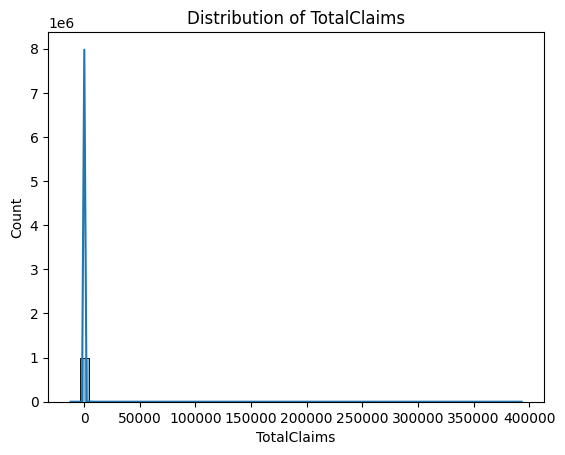

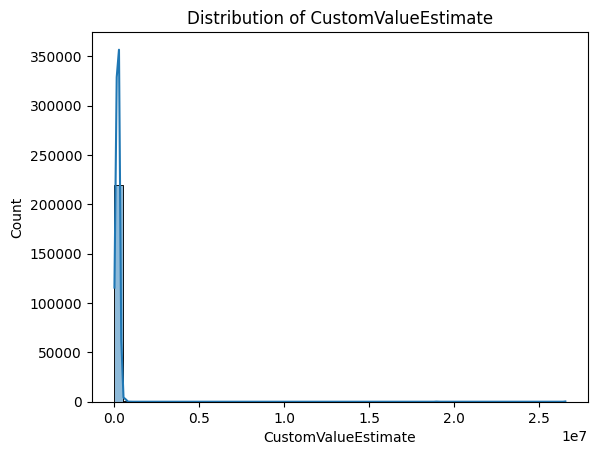

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

# Histogram: TotalClaims and CustomValueEstimate
sns.histplot(df['TotalClaims'], bins=50, kde=True)
plt.title("Distribution of TotalClaims")
plt.show()

sns.histplot(df['CustomValueEstimate'], bins=50, kde=True)
plt.title("Distribution of CustomValueEstimate")
plt.show()


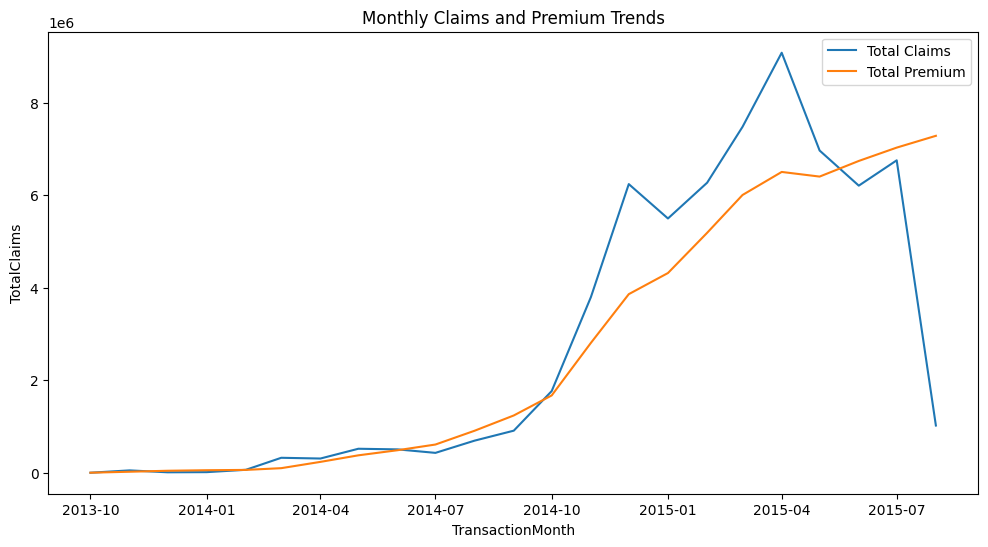

In [16]:
monthly_stats = df.groupby(df['TransactionMonth'].dt.to_period("M")).agg({
    'TotalClaims': 'sum',
    'TotalPremium': 'sum'
}).reset_index()

monthly_stats['TransactionMonth'] = monthly_stats['TransactionMonth'].dt.to_timestamp()

# Plot claim trends over time
plt.figure(figsize=(12,6))
sns.lineplot(data=monthly_stats, x='TransactionMonth', y='TotalClaims', label='Total Claims')
sns.lineplot(data=monthly_stats, x='TransactionMonth', y='TotalPremium', label='Total Premium')
plt.title('Monthly Claims and Premium Trends')
plt.show()


In [19]:
top_vehicles = df.groupby('make')['TotalClaims'].mean().sort_values(ascending=False).head(10)
print("Top 10 Vehicle Makes by Average TotalClaims:")
print(top_vehicles)


Top 10 Vehicle Makes by Average TotalClaims:
make
SUZUKI                                 419.634546
JMC                                    191.684795
HYUNDAI                                174.215195
MARCOPOLO                              156.794806
AUDI                                   137.843083
POLARSUN                               134.044800
B.A.W                                  132.934016
FIAT                                   108.625642
BMW                                     90.558050
IVECO                                   89.667017
Name: TotalClaims, dtype: float64


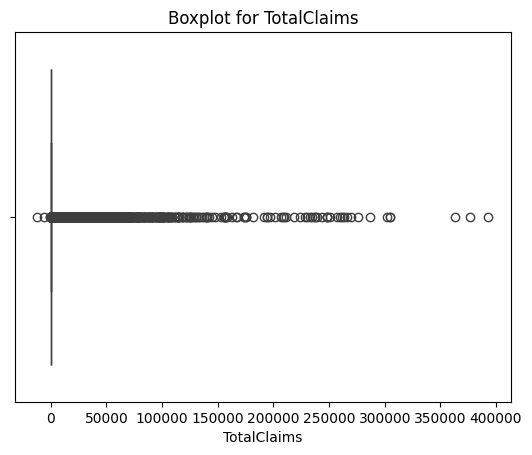

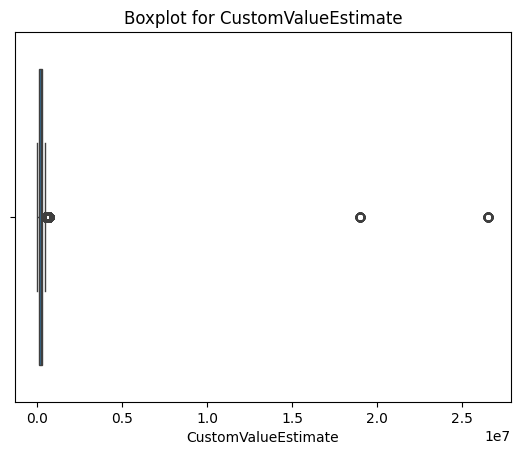

In [20]:
sns.boxplot(x=df['TotalClaims'])
plt.title("Boxplot for TotalClaims")
plt.show()

sns.boxplot(x=df['CustomValueEstimate'])
plt.title("Boxplot for CustomValueEstimate")
plt.show()


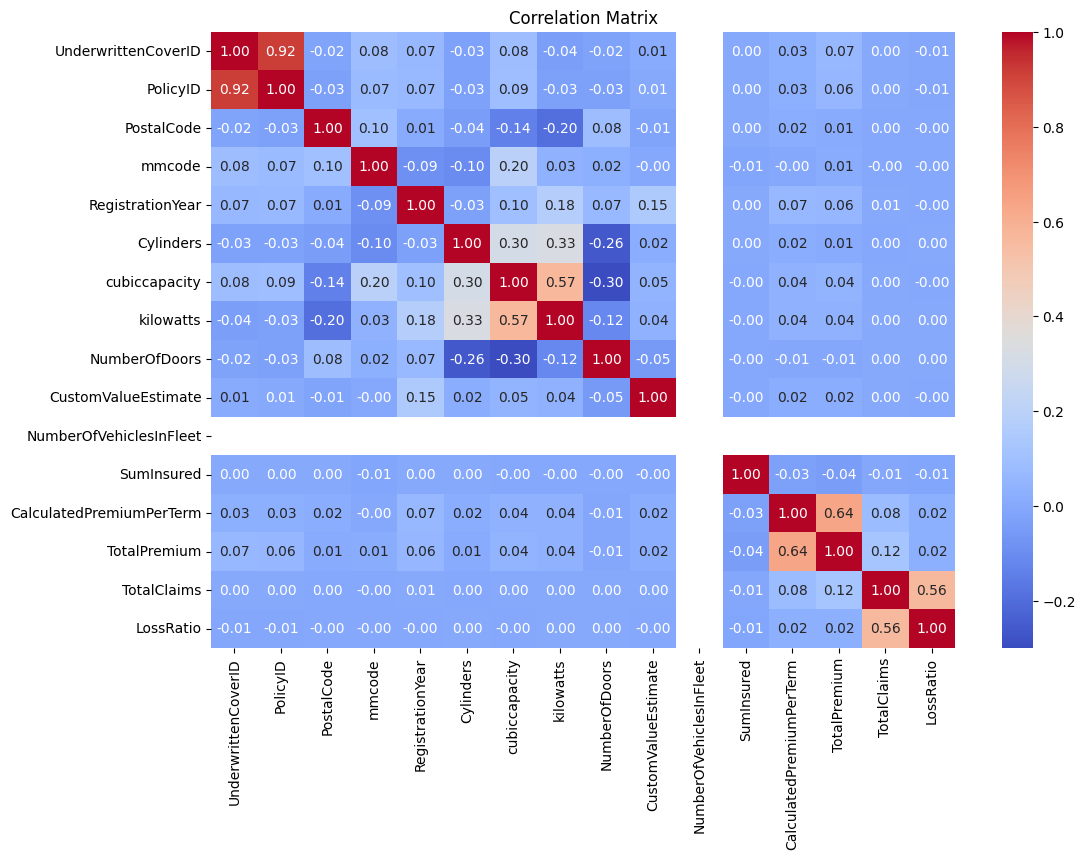

In [21]:
numeric_cols = df.select_dtypes(include='number')
corr_matrix = numeric_cols.corr()

plt.figure(figsize=(12,8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()


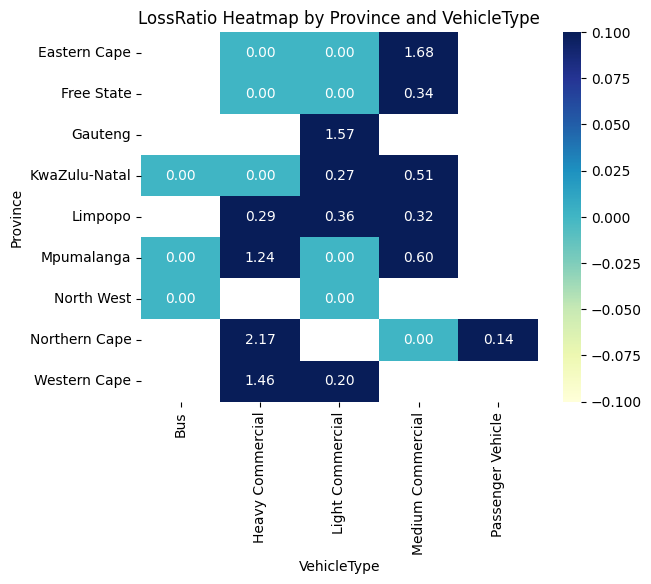

In [22]:
# Heatmap: LossRatio by Province and VehicleType
pivot = df.pivot_table(index='Province', columns='VehicleType', values='LossRatio', aggfunc='mean')
sns.heatmap(pivot, cmap='YlGnBu', annot=True, fmt=".2f")
plt.title("LossRatio Heatmap by Province and VehicleType")
plt.show()


In [10]:
import pandas as pd
file_path = '../data/raw/MachineLearningRating_v3.txt' 
#|  pipe character
df= pd.read_csv(file_path , sep='|')

# Define Claim Frequency
df["ClaimOccurred"] = df["TotalClaims"].apply(lambda x: 1 if x > 0 else 0)


# Define Margin
df["Margin"] = df["TotalPremium"] - df["TotalClaims"]

# Optional: Drop NaNs or invalid entries
df = df.dropna(subset=["TotalPremium", "TotalClaims", "Province", "PostalCode", "Gender"])


C:\Users\KIDIST\AppData\Local\Temp\ipykernel_14976\1393974611.py:4: DtypeWarning: Columns (32,37) have mixed types. Specify dtype option on import or set low_memory=False.
  df= pd.read_csv(file_path , sep='|')


In [7]:
df.columns.tolist()


['UnderwrittenCoverID',
 'PolicyID',
 'TransactionMonth',
 'IsVATRegistered',
 'Citizenship',
 'LegalType',
 'Title',
 'Language',
 'Bank',
 'AccountType',
 'MaritalStatus',
 'Gender',
 'Country',
 'Province',
 'PostalCode',
 'MainCrestaZone',
 'SubCrestaZone',
 'ItemType',
 'mmcode',
 'VehicleType',
 'RegistrationYear',
 'make',
 'Model',
 'Cylinders',
 'cubiccapacity',
 'kilowatts',
 'bodytype',
 'NumberOfDoors',
 'VehicleIntroDate',
 'CustomValueEstimate',
 'AlarmImmobiliser',
 'TrackingDevice',
 'CapitalOutstanding',
 'NewVehicle',
 'WrittenOff',
 'Rebuilt',
 'Converted',
 'CrossBorder',
 'NumberOfVehiclesInFleet',
 'SumInsured',
 'TermFrequency',
 'CalculatedPremiumPerTerm',
 'ExcessSelected',
 'CoverCategory',
 'CoverType',
 'CoverGroup',
 'Section',
 'Product',
 'StatutoryClass',
 'StatutoryRiskType',
 'TotalPremium',
 'TotalClaims']

In [12]:
from scipy.stats import f_oneway

# Grouping by Province
province_groups = df.groupby('Province')

# Claim Frequency
claim_freqs = [group["ClaimOccurred"] for name, group in province_groups]
f_stat_freq, p_val_freq = f_oneway(*claim_freqs)

# Claim Severity (only for rows with claims)
claim_sev = [group[group["ClaimOccurred"] == 1]["TotalClaims"] for name, group in province_groups]
f_stat_sev, p_val_sev = f_oneway(*claim_sev)

# Margin
margins = [group["Margin"] for name, group in province_groups]
f_stat_margin, p_val_margin = f_oneway(*margins)

print("Province Risk Differences")
print(f"Claim Frequency p-value: {p_val_freq}")
print(f"Claim Severity p-value: {p_val_sev}")
print(f"Margin p-value: {p_val_margin}")


Province Risk Differences
Claim Frequency p-value: 9.245710131121655e-20
Claim Severity p-value: 5.697438983975486e-06
Margin p-value: 0.0006532415735058966


In [ ]:
zip_counts = df['PostalCode'].value_counts()
top_zips = zip_counts.index[:2]

group1 = df[df["PostalCode"] == top_zips[0]]
group2 = df[df["PostalCode"] == top_zips[1]]

from scipy.stats import ttest_ind

# Claim Frequency
freq1 = group1["ClaimOccurred"]
freq2 = group2["ClaimOccurred"]
_, p_freq = ttest_ind(freq1, freq2)

# Claim Severity
sev1 = group1[group1["ClaimOccurred"] == 1]["TotalClaims"]
sev2 = group2[group2["ClaimOccurred"] == 1]["TotalClaims"]
_, p_sev = ttest_ind(sev1, sev2)

# Margin
margin1 = group1["Margin"]
margin2 = group2["Margin"]
_, p_margin = ttest_ind(margin1, margin2)

print("postal Code Risk Differences")
print(f"Claim Frequency p-value: {p_freq}")
print(f"Claim Severity p-value: {p_sev}")
print(f"Margin p-value: {p_margin}")


Zip Code Risk Differences
Claim Frequency p-value: 0.052452879561473535
Claim Severity p-value: 0.6735989697966227
Margin p-value: 0.19590898368555748


In [15]:
male = df[df["Gender"] == "Male"]
female = df[df["Gender"] == "Female"]

# Claim Frequency
_, p_freq_gender = ttest_ind(male["ClaimOccurred"], female["ClaimOccurred"])

# Claim Severity
_, p_sev_gender = ttest_ind(male[male["ClaimOccurred"] == 1]["TotalClaims"],
                            female[female["ClaimOccurred"] == 1]["TotalClaims"])

# Margin
_, p_margin_gender = ttest_ind(male["Margin"], female["Margin"])

print("Gender Risk Differences")
print(f"Claim Frequency p-value: {p_freq_gender}")
print(f"Claim Severity p-value: {p_sev_gender}")
print(f"Margin p-value: {p_margin_gender}")


Gender Risk Differences
Claim Frequency p-value: 0.8404980845002314
Claim Severity p-value: 0.6760156776445874
Margin p-value: 0.833368001967537


In [4]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.metrics import mean_squared_error, r2_score, classification_report, roc_auc_score
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
#import xgboost as xgb
#import shap
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure df is defined
if 'df' not in globals():
	file_path = '../data/raw/MachineLearningRating_v3.txt'
	df = pd.read_csv(file_path, sep='|')
	df["ClaimOccurred"] = df["TotalClaims"].apply(lambda x: 1 if x > 0 else 0)
	df["Margin"] = df["TotalPremium"] - df["TotalClaims"]
	df = df.dropna(subset=["TotalPremium", "TotalClaims", "Province", "PostalCode", "Gender"])

# For claim severity (only rows with ClaimOccurred == 1)
df_claims = df[df['ClaimOccurred'] == 1].copy()

# For claim probability and premium modeling (full dataset)
df_full = df.copy()


# Simple fill for missing values (you may customize this)
df_claims.fillna(0, inplace=True)
df_full.fillna(0, inplace=True)
categorical_cols = df.select_dtypes(include='object').columns

# Label Encoding or One-hot encoding
df_claims = pd.get_dummies(df_claims, columns=categorical_cols, drop_first=True)
df_full = pd.get_dummies(df_full, columns=categorical_cols, drop_first=True)

# ---- Claim Severity ----
X_claim = df_claims.drop(columns=['TotalClaims'])
y_claim = df_claims['TotalClaims']
Xc_train, Xc_test, yc_train, yc_test = train_test_split(X_claim, y_claim, test_size=0.2, random_state=42)

# ---- Claim Probability ----
Xp = df_full.drop(columns=['ClaimOccurred'])
yp = df_full['ClaimOccurred']
Xp_train, Xp_test, yp_train, yp_test = train_test_split(Xp, yp, test_size=0.2, random_state=42)



C:\Users\KIDIST\AppData\Local\Temp\ipykernel_7024\1975631472.py:16: DtypeWarning: Columns (32,37) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path, sep='|')
C:\Users\KIDIST\AppData\Local\Temp\ipykernel_7024\1975631472.py:29: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_claims.fillna(0, inplace=True)


MemoryError: Unable to allocate 948. MiB for an array with shape (1003, 990562) and data type bool

In [5]:
rf_reg = RandomForestRegressor(n_estimators=100, random_state=42)
rf_reg.fit(Xc_train, yc_train)
y_pred_rf = rf_reg.predict(Xc_test)

# Evaluation
rmse_rf = np.sqrt(mean_squared_error(yc_test, y_pred_rf))
r2_rf = r2_score(yc_test, y_pred_rf)
print("Random Forest RMSE:", rmse_rf)
print("Random Forest R^2:", r2_rf)


NameError: name 'Xc_train' is not defined

In [ ]:
xgb_clf = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss')
xgb_clf.fit(Xp_train, yp_train)
y_pred_xgb = xgb_clf.predict(Xp_test)
y_proba_xgb = xgb_clf.predict_proba(Xp_test)[:,1]

print(classification_report(yp_test, y_pred_xgb))
print("ROC-AUC:", roc_auc_score(yp_test, y_proba_xgb))
